In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

In [ ]:

df = pd.read_csv("diabetic_data.csv")

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No 

In [ ]:
print("Missing values:")
print((df == "?").sum())

Missing values:
encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     

In [ ]:
print("Dataset information:")
print(df.info())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-n

In [ ]:
df["target"] = (df["readmitted"] == "<30").astype(int)

print("Target distribution:")
print(df["target"].value_counts())

Target distribution:
target
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

X = df[features]
y = df["target"]

print("Selected features:")
print(X.head())

Selected features:
   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0                 1                  41               0                1   
1                 3                  59               0               18   
2                 2                  11               5               13   
3                 2                  44               1               16   
4                 1                  51               0                8   

   number_outpatient  number_emergency  number_inpatient  number_diagnoses  
0                  0                 0                 0                 1  
1                  0                 0                 0                 9  
2                  2                 0                 1                 6  
3                  0                 0                 0                 7  
4                  0                 0                 0                 5  


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (81412, 8)
Testing data shape: (20354, 8)


In [ ]:
model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients)

Intercept:
[-0.84811028]

Coefficients:
              Feature  Coefficient
0    time_in_hospital     0.028512
1  num_lab_procedures    -0.000013
2      num_procedures    -0.026640
3     num_medications     0.006715
4   number_outpatient    -0.004623
5    number_emergency     0.051635
6    number_inpatient     0.290989
7    number_diagnoses     0.052143


In [ ]:
y_probability = model.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_probability[:10])

First 10 predicted probabilities:
[0.53490923 0.43214509 0.47315062 0.550471   0.51441574 0.40427736
 0.38809622 0.38076052 0.77259828 0.61448098]


In [ ]:
print("Minimum probability:", y_probability.min())
print("Maximum probability:", y_probability.max())
print("Mean probability:", y_probability.mean())
print("Predicted 1s:", (y_probability >= 0.5).sum())

Minimum probability: 0.30816432032555263
Maximum probability: 0.997560241430521
Mean probability: 0.4801049972509951
Predicted 1s: 6366


In [ ]:
auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:")
print(auc)

ROC-AUC Score:
0.6360320565966029


In [ ]:
threshold = 0.5

y_pred = (y_probability >= threshold).astype(int)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[1 0 0 1 1 0 0 0 1 1]


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[18050    33]
 [ 2237    34]]


In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 18050
False Positives: 33
False Negatives: 2237
True Positives : 34


In [ ]:
FN_COST = 5
FP_COST = 1

false_negative_cost = fn * FN_COST
false_positive_cost = fp * FP_COST

total_cost = false_negative_cost + false_positive_cost

print("Clinical Cost Analysis")
print("----------------------")
print("False Negative Cost:", false_negative_cost)
print("False Positive Cost:", false_positive_cost)
print("Total Clinical Cost:", total_cost)

Clinical Cost Analysis
----------------------
False Negative Cost: 11185
False Positive Cost: 33
Total Clinical Cost: 11218


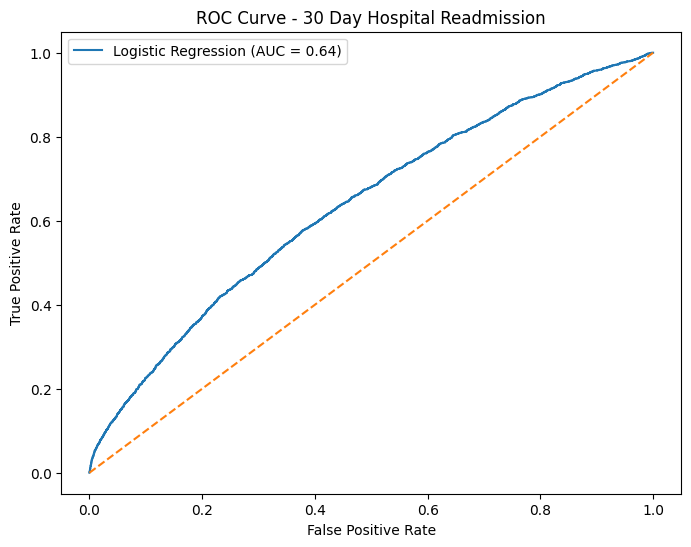

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30 Day Hospital Readmission")

plt.legend()

plt.show()

In [ ]:
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

Train AUC: 0.6293918599626466
Test AUC: 0.6360320565966029
